# [5.0] DESI DR1 x LSST DP2 Data

In this notebook, we will:
- **move the catalog** at NERSC to provide a public endpoint of our DESI DR1 catalog
- **crossmatch** the NERSC-hosted DESI DR1 catalog with the LSST DP2 Data at USDF 
  - specifically, the **DP2 v30_0_6 dia_object_collection** (accessed May 28)
  - as well as the **DP2 v30_0_6 object_collection** (accessed June 3)
- **save** the resulting catalog on USDF
- discuss **performance and resource use** of the crossmatch

## Pre-set up: move catalog to public NERSC dir

First, I moved the catalog we've been using through the last four sections:
```bash
mv /global/cfs/cdirs/cosmo/users/olynn/desi-dr1-main-dark \
   /global/cfs/cdirs/cosmo/www/users/olynn/desi-dr1-main-dark
```

And I set the permissions on noth my public dir and the catalog inside it:
```bash
chmod o+rX /global/cfs/cdirs/cosmo/www/users/olynn
chmod o+rX -R /global/cfs/cdirs/cosmo/www/users/olynn/desi-dr1-main-dark
```

## Set up

In [1]:
import time
from pathlib import Path
import shutil

import lsdb
import matplotlib.pyplot as plt
from dask.distributed import Client, performance_report
from hats.io.validation import is_valid_catalog

In [ ]:
# Clear and remake the tmp directory we use for dask.

tmp_directory = Path("/sdf/data/rubin/user/olynn/tmp")
if tmp_directory.exists():
    tmp_directory.mkdir(parents=True, exist_ok=True)


# Make a dask client.

client = Client(
    n_workers=32,
    memory_limit="14GB",
    threads_per_worker=2, 
    local_directory=tmp_directory
)

In [27]:
import socket
import os

print (os.getpid())

username = os.getenv("USER")
current_compute_node = socket.gethostname()
dashboard_port = client.scheduler_info()['services']['dashboard']

print(f"Run this in a local shell:")
print(f"  ssh -L 8787:{current_compute_node}:{dashboard_port} -J {username}@s3dflogin.slac.stanford.edu {username}@{current_compute_node}")
print(f"\nThen open: http://localhost:8787/status")

3839706
Run this in a local shell:
  ssh -L 8787:sdfiana033:17295 -J olynn@s3dflogin.slac.stanford.edu olynn@sdfiana033

Then open: http://localhost:8787/status


## Load catalogs

### Load DESI

In [4]:
desi_cat = lsdb.open_catalog("https://portal.nersc.gov/project/cosmo/users/olynn/desi-dr1-main-dark/")
desi_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z
npartitions=5769,,,,,,,,
"Order: 6, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12286",...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12287",...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi-dr1-main-dark'}>)

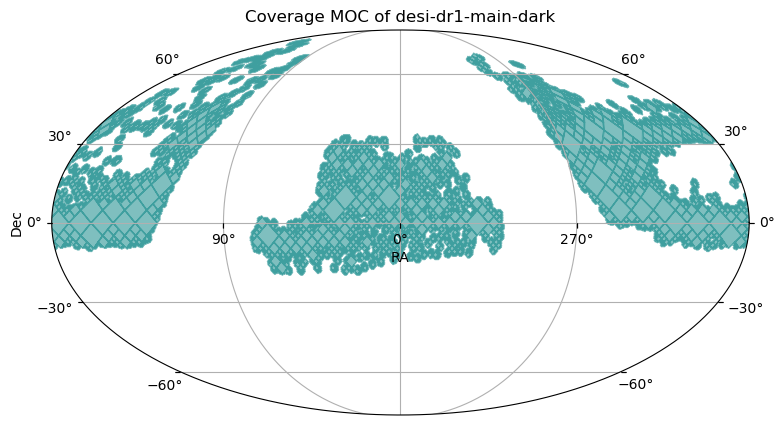

In [5]:
desi_cat.plot_coverage()

### Load DP2 dia_object

In [43]:
dp2_dia_obj = lsdb.open_catalog("/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_6/dia_object_collection")
dp2_dia_obj

,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource
npartitions=33850,,,,,,,
"Order: 4, Pixel: 1059",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ..."
"Order: 5, Pixel: 4249",...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12283",...,...,...,...,...,...,...
"Order: 11, Pixel: 50315377",...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of dia_object_lc'}>)

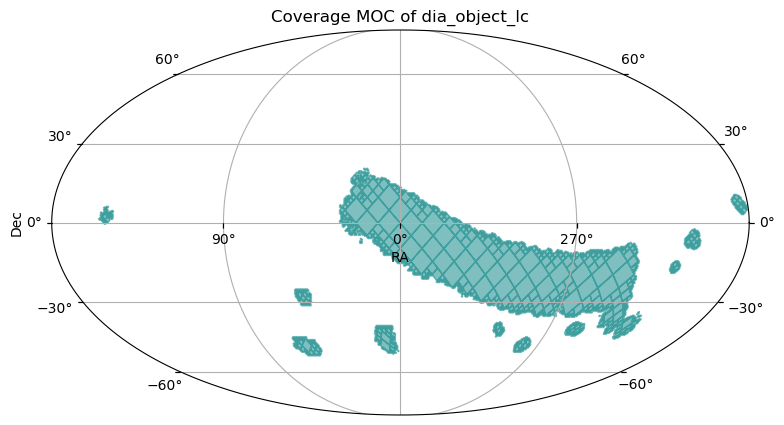

In [44]:
dp2_dia_obj.plot_coverage()

### Load DP2 object

In [6]:
dp2_object = lsdb.open_catalog(
    "/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_6/object_collection",
    columns=["objectId", "coord_ra", "coord_dec", "r_psfMag", "r_psfMagErr"]
    )
dp2_object

,objectId,coord_ra,coord_dec,r_psfMag,r_psfMagErr
npartitions=110123,,,,,
"Order: 5, Pixel: 170",int64[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow]
"Order: 8, Pixel: 271295",...,...,...,...,...
...,...,...,...,...,...
"Order: 7, Pixel: 196561",...,...,...,...,...
"Order: 6, Pixel: 49141",...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of object_lc'}>)

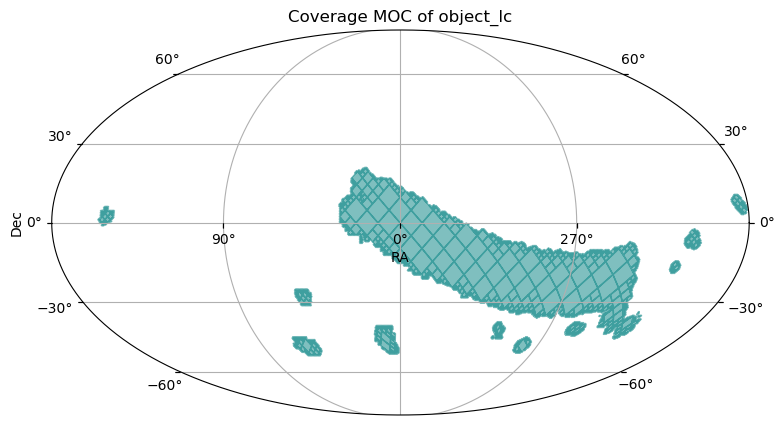

In [7]:
dp2_object.plot_coverage()

## Do crossmatches

### DESI x LSST DP2 dia_obj

In [45]:
desi_x_dp2_dia_obj = desi_cat.crossmatch(dp2_dia_obj, suffix_method="overlapping_columns", suffixes=("_desi", "_lsst_dp2"))

In [ ]:
start = time.perf_counter()

catalog_name = "desi_x_lsst_dp2_dia_obj"
target_user_dir = Path("/sdf/data/rubin/user/olynn")
with performance_report(filename="crossmatch_report_dia_obj.html"):
    desi_x_dp2_dia_obj.write_catalog(
        base_catalog_path=target_user_dir,
        catalog_name=catalog_name,
    )

elapsed = time.perf_counter() - start

In [13]:
print(f"Crossmatch took {int(elapsed/60):d}m {elapsed%60:.1f}s")

Crossmatch took 41m 50.6s


### DESI x LSST DP2 object

In [28]:
desi_x_dp2_object = desi_cat.crossmatch(dp2_object, suffix_method="overlapping_columns", suffixes=("_desi", "_lsst_dp2"))

In [29]:
desi_x_dp2_object

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z,objectId,coord_ra,coord_dec,r_psfMag,r_psfMagErr,_dist_arcsec
npartitions=24639,,,,,,,,,,,,,,
"Order: 6, Pixel: 680",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...",int64[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow]
"Order: 6, Pixel: 682",...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 196561",...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 49141",...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [ ]:
start = time.perf_counter()

catalog_name = "desi_x_lsst_dp2_object"
target_user_dir = Path("/sdf/data/rubin/user/olynn")
with performance_report(filename="crossmatch_report_object.html"):
    desi_x_dp2_object.write_catalog(
        base_catalog_path=target_user_dir,
        catalog_name=catalog_name,
    )

elapsed = time.perf_counter() - start

In [31]:
print(f"Crossmatch took {int(elapsed/60):d}m {elapsed%60:.1f}s")

Crossmatch took 27m 59.9s


## Verify crossmatched catalogs

### DESI x LSST DP2 dia_obj

In [19]:
# Check that the catalog was written correctly

catalog_name = "desi_x_lsst_dp2_dia_obj"
output_catalog = target_user_dir / catalog_name

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

Validating catalog at path /sdf/data/rubin/user/olynn/desi_x_lsst_dp2_dia_obj ... 
Found 2125 partitions.
Approximate coverage is 3.85 % of the sky.


True

In [20]:
# Calculate size of the catalog on disk

! du -sh $output_catalog

/sdf/group/rubin/sw/conda/envs/lsst-scipipe-13.0.0/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=194304) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


7.3G	/sdf/data/rubin/user/olynn/desi_x_lsst_dp2_dia_obj


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi_x_lsst_dp2_dia_obj'}>)

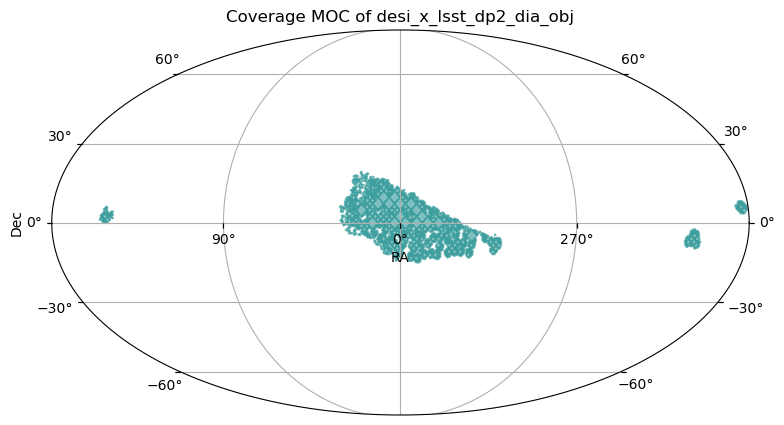

In [21]:
# Plot coverage

desi_x_dp2_dia_obj = lsdb.open_catalog(output_catalog)
desi_x_dp2_dia_obj.plot_coverage()

In [27]:
# See the first few rows

df_dia_obj = desi_x_dp2_dia_obj.head(5)
df_dia_obj

TARGETID   TARGET_RA  TARGET_DEC         Z  \
_healpix_29                                                                
1203863513569649040  39627437792825537  351.428181  -14.683122  1.368533   
1203863976572888979  39627437792823928  351.350538   -14.67635  0.146449   
1204005882254261797  39627455413094458  353.658806  -14.040638  3.617634   
1204008106340562315  39627455413092836  353.583011   -13.94792  1.228033   
1204008148320016189  39627455413094471  353.659641  -14.004045   3.09752   

                         ZERR  \
_healpix_29                     
1203863513569649040  0.000138   
1203863976572888979  0.000004   
1204005882254261797   0.00031   
1204008106340562315  0.000786   
1204008148320016189  0.000161   

                                                             spectra_b  \
_healpix_29                                                              
1203863513569649040  [{wavelength: 3600.0, flux: 5.040675, ivar: 0....   
1203863976572888979  [{wavelength: 3600.0, flux: 64.870834, ivar: 0...   
1204005882254261797  [{wavelength: 3600.0, flux: -0.637333, ivar: 0...   
1204008106340562315  [{wavelength: 3600.0, flux: 3.158296, ivar: 0....   
1204008148320016189  [{wavelength: 3600.0, flux: -2.019307, ivar: 0...   

                                                             spectra_r  \
_healpix_29                                                              
1203863513569649040  [{wavelength: 5760.0, flux: 4.024427, ivar: 0....   
1203863976572888979  [{wavelength: 5760.0, flux: 36.507702, ivar: 0...   
1204005882254261797  [{wavelength: 5760.0, flux: 3.039543, ivar: 0....   
1204008106340562315  [{wavelength: 5760.0, flux: 3.824352, ivar: 0....   
1204008148320016189  [{wavelength: 5760.0, flux: 4.587873, ivar: 0....   

                                                             spectra_z  \
_healpix_29                                                              
1203863513569649040  [{wavelength: 7520.0, flux: 0.567026, ivar: 2....   
1203863976572888979  [{wavelength: 7520.0, flux: 187.865128, ivar: ...   
1204005882254261797  [{wavelength: 7520.0, flux: 1.360092, ivar: 6....   
1204008106340562315  [{wavelength: 7520.0, flux: 0.007672, ivar: 8....   
1204008148320016189  [{wavelength: 7520.0, flux: 0.922159, ivar: 7....   

                           dec         diaObjectId  nDiaSources          ra  \
_healpix_29                                                                   
1203863513569649040 -14.683135  770721298467782915            1  351.428182   
1203863976572888979  -14.67635  770721367187259405           28  351.350518   
1204005882254261797 -14.040633  770738134739583189            4  353.658795   
1204008106340562315 -13.947923  770738821934350543            4  353.583073   
1204008148320016189 -14.004058  770738134739583163            2  353.659605   

                     tract                              diaObjectForcedSource  \
_healpix_29                                                                     
1203863513569649040   7297  [{band: 'i', coord_dec: -14.683135, coord_ra: ...   
1203863976572888979   7297  [{band: 'i', coord_dec: -14.67635, coord_ra: 3...   
1204005882254261797   7299  [{band: 'r', coord_dec: -14.040633, coord_ra: ...   
1204008106340562315   7299  [{band: 'r', coord_dec: -13.947923, coord_ra: ...   
1204008148320016189   7299  [{band: 'r', coord_dec: -14.004058, coord_ra: ...   

                                                             diaSource  \
_healpix_29                                                              
1203863513569649040  [{band: 'g', centroid_flag: False, dec: -14.68...   
1203863976572888979  [{band: 'i', centroid_flag: False, dec: -14.67...   
1204005882254261797  [{band: 'g', centroid_flag: False, dec: -14.04...   
1204008106340562315  [{band: 'g', centroid_flag: False, dec: -13.94...   
1204008148320016189  [{band: 'r', centroid_flag: False, dec: -14.00...   

                     _dist_arcsec  
_healpix_29                    

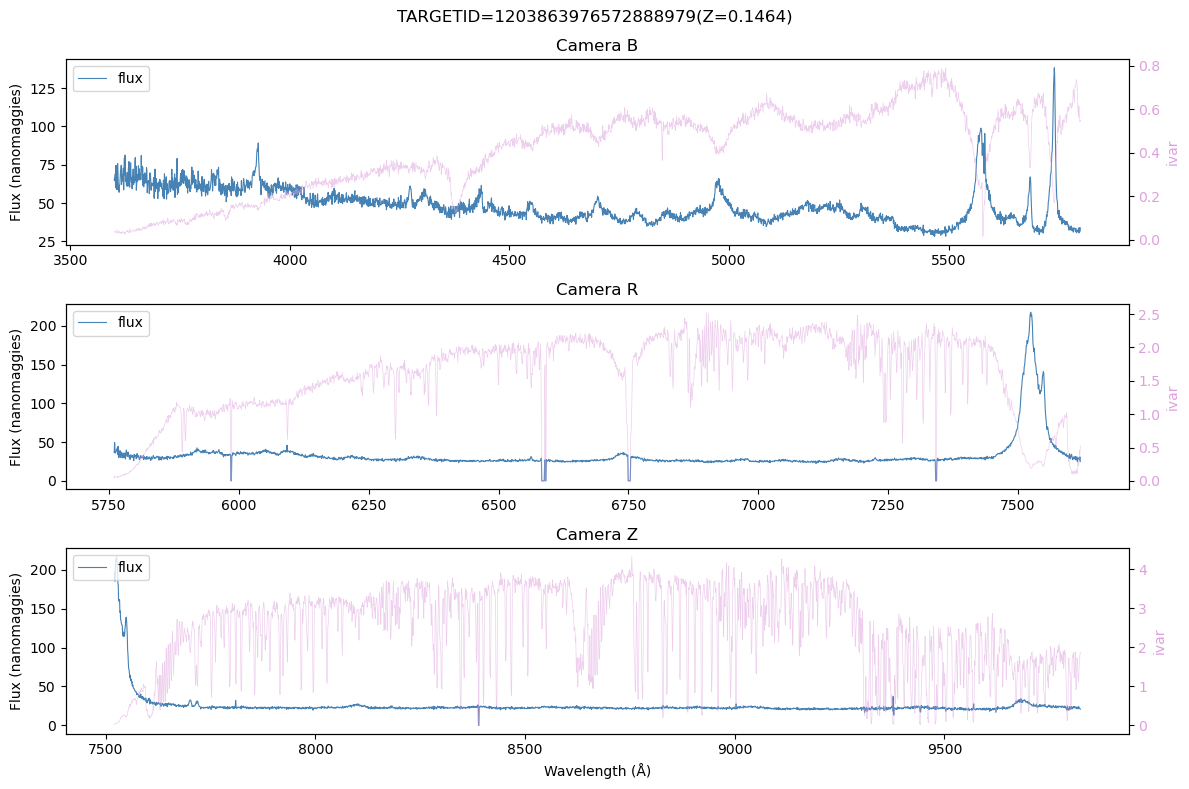

In [28]:
# Plot spectra of a row

target_idx = 1  # Picking 1 for the example, as it has the lowest redshift and a nice spectrum :)

def plot_spectra(df, target_idx):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
    colors = ["steelblue", "plum"]

    # Iterate over the three cameras and plot the spectra for the target at target_idx.
    for ax, cam in zip(axes, ["b", "r", "z"]):
        # Get the spectrum.
        spec = df[f"spectra_{cam}"].iloc[target_idx]

        # Plot flux on the primary y-axis.
        ax.plot(spec["wavelength"], spec["flux"], lw=0.8, color=colors[0], label="flux")
        
        # Plot ivar on the secondary y-axis.
        ax_twin = ax.twinx()
        ax_twin.plot(spec["wavelength"], spec["ivar"], lw=0.5, color=colors[1], alpha=0.5, label="ivar")
        ax_twin.set_ylabel("ivar", color=colors[1])
        ax_twin.tick_params(axis="y", labelcolor=colors[1])
        
        # Set labels and title for the primary y-axis.
        ax.set_ylabel("Flux (nanomaggies)") # https://desidatamodel.readthedocs.io/en/latest/DESI_SPECTRO_DATA/NIGHT/EXPID/fibermap-EXPID.html#required-data-table-columns:~:text=nanomaggies
        ax.set_title(f"Camera {cam.upper()}")
        ax.legend(loc="upper left")

    # Set x-axis label and overall figure title.
    axes[-1].set_xlabel("Wavelength (Å)")
    fig.suptitle(f"TARGETID={df.index[target_idx]}(Z={df['Z'].iloc[target_idx]:.4f})")
    plt.tight_layout()
    plt.show()

plot_spectra(df_dia_obj, target_idx)

In [37]:
# Print first 2 rows of dataframe - useful for copy/pasting into documentation

df_dia_obj.iloc[:2]

TARGETID   TARGET_RA  TARGET_DEC         Z  \
_healpix_29                                                                
1203863513569649040  39627437792825537  351.428181  -14.683122  1.368533   
1203863976572888979  39627437792823928  351.350538   -14.67635  0.146449   

                         ZERR  \
_healpix_29                     
1203863513569649040  0.000138   
1203863976572888979  0.000004   

                                                             spectra_b  \
_healpix_29                                                              
1203863513569649040  [{wavelength: 3600.0, flux: 5.040675, ivar: 0....   
1203863976572888979  [{wavelength: 3600.0, flux: 64.870834, ivar: 0...   

                                                             spectra_r  \
_healpix_29                                                              
1203863513569649040  [{wavelength: 5760.0, flux: 4.024427, ivar: 0....   
1203863976572888979  [{wavelength: 5760.0, flux: 36.507702, ivar: 0...   

                                                             spectra_z  \
_healpix_29                                                              
1203863513569649040  [{wavelength: 7520.0, flux: 0.567026, ivar: 2....   
1203863976572888979  [{wavelength: 7520.0, flux: 187.865128, ivar: ...   

                           dec         diaObjectId  nDiaSources          ra  \
_healpix_29                                                                   
1203863513569649040 -14.683135  770721298467782915            1  351.428182   
1203863976572888979  -14.67635  770721367187259405           28  351.350518   

                     tract                              diaObjectForcedSource  \
_healpix_29                                                                     
1203863513569649040   7297  [{band: 'i', coord_dec: -14.683135, coord_ra: ...   
1203863976572888979   7297  [{band: 'i', coord_dec: -14.67635, coord_ra: 3...   

                                                             diaSource  \
_healpix_29                                                              
1203863513569649040  [{band: 'g', centroid_flag: False, dec: -14.68...   
1203863976572888979  [{band: 'i', centroid_flag: False, dec: -14.67...   

                     _dist_arcsec  
_healpix_29                        
1203863513569649040      0.045792  
1203863976572888979      0.071685

In [42]:
import hats

hats_cat = hats.read_hats("/sdf/data/rubin/user/olynn/desi_x_lsst_dp2_dia_obj")
hats_cat.aggregate_column_statistics()

,min_value,max_value,null_count,row_count
column_names,,,,
TARGETID,-119319429,616097122244100225,0,82279
TARGET_RA,0.0006671232307283737,359.99963314764267,0,82279
...,...,...,...,...
diaSource.yErr,0.0004174975911155343,580.2407836914062,22,627432
_dist_arcsec,0.00041979962653116077,0.9999030993665052,0,82279


### DESI x LSST DP2 object

In [32]:
# Check that the catalog was written correctly

catalog_name = "desi_x_lsst_dp2_object"
output_catalog = target_user_dir / catalog_name

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

Validating catalog at path /sdf/data/rubin/user/olynn/desi_x_lsst_dp2_object ... 
Found 24553 partitions.


Approximate coverage is 3.57 % of the sky.


True

In [33]:
# Calculate size of the catalog on disk

! du -sh $output_catalog

/sdf/group/rubin/sw/conda/envs/lsst-scipipe-13.0.0/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=3839706) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


94G	/sdf/data/rubin/user/olynn/desi_x_lsst_dp2_object


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi_x_lsst_dp2_object'}>)

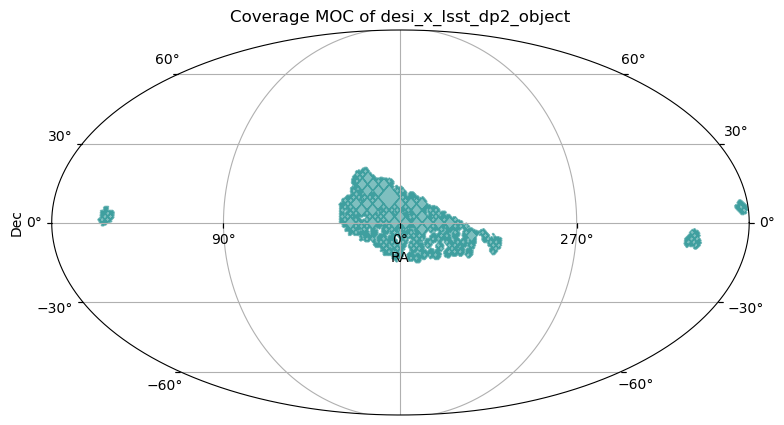

In [34]:
# Plot coverage

desi_x_dp2_object = lsdb.open_catalog(output_catalog)
desi_x_dp2_object.plot_coverage()

In [35]:
# See the first few rows

df_object = desi_x_dp2_object.head(5)
df_object

TARGETID  TARGET_RA  TARGET_DEC         Z  \
_healpix_29                                                             
47991521810220274  39628230637916670  23.190178   18.856721  1.489172   
47992039361544743  39628236367335481  23.165036   18.888546  0.880572   
47992100620057397  39628236367335292  23.155519   18.914039  1.152822   
47992192731200784  39628236367335280   23.15489   18.916803  2.572776   
47993688527754822  39628236367334652  23.122677   18.927627  0.942062   

                       ZERR  \
_healpix_29                   
47991521810220274  0.000865   
47992039361544743  0.000065   
47992100620057397   0.00007   
47992192731200784  0.000242   
47993688527754822  0.000079   

                                                           spectra_b  \
_healpix_29                                                            
47991521810220274  [{wavelength: 3600.0, flux: 0.002376, ivar: 0....   
47992039361544743  [{wavelength: 3600.0, flux: 0.322199, ivar: 0....   
47992100620057397  [{wavelength: 3600.0, flux: 6.202363, ivar: 0....   
47992192731200784  [{wavelength: 3600.0, flux: 0.647978, ivar: 0....   
47993688527754822  [{wavelength: 3600.0, flux: 4.569196, ivar: 0....   

                                                           spectra_r  \
_healpix_29                                                            
47991521810220274  [{wavelength: 5760.0, flux: 0.180997, ivar: 2....   
47992039361544743  [{wavelength: 5760.0, flux: 7.639961, ivar: 0....   
47992100620057397  [{wavelength: 5760.0, flux: -0.083245, ivar: 2...   
47992192731200784  [{wavelength: 5760.0, flux: 2.687236, ivar: 2....   
47993688527754822  [{wavelength: 5760.0, flux: 0.22266, ivar: 3.0...   

                                                           spectra_z  \
_healpix_29                                                            
47991521810220274  [{wavelength: 7520.0, flux: 0.920303, ivar: 8....   
47992039361544743  [{wavelength: 7520.0, flux: -0.006492, ivar: 1...   
47992100620057397  [{wavelength: 7520.0, flux: 0.340336, ivar: 11...   
47992192731200784  [{wavelength: 7520.0, flux: 1.91442, ivar: 7.4...   
47993688527754822  [{wavelength: 7520.0, flux: 0.198024, ivar: 8....   

                             objectId   coord_ra  coord_dec  r_psfMag  \
_healpix_29                                                             
47991521810220274  805469645476725267  23.190189  18.856733      <NA>   
47992039361544743  805469645476725414  23.165003  18.888799      <NA>   
47992100620057397  805469645476725527  23.155478  18.914035      <NA>   
47992192731200784  805469645476725536  23.154885  18.916796      <NA>   
47993688527754822  805469645476725583  23.122872  18.927774      <NA>   

                   r_psfMagErr  _dist_arcsec  
_healpix_29                                   
47991521810220274         <NA>       0.05855  
47992039361544743         <NA>      0.919738  
47992100620057397         <NA>      0.139479  
47992192731200784         <NA>      0.028512  
47993688527754822         <NA>       0.85188

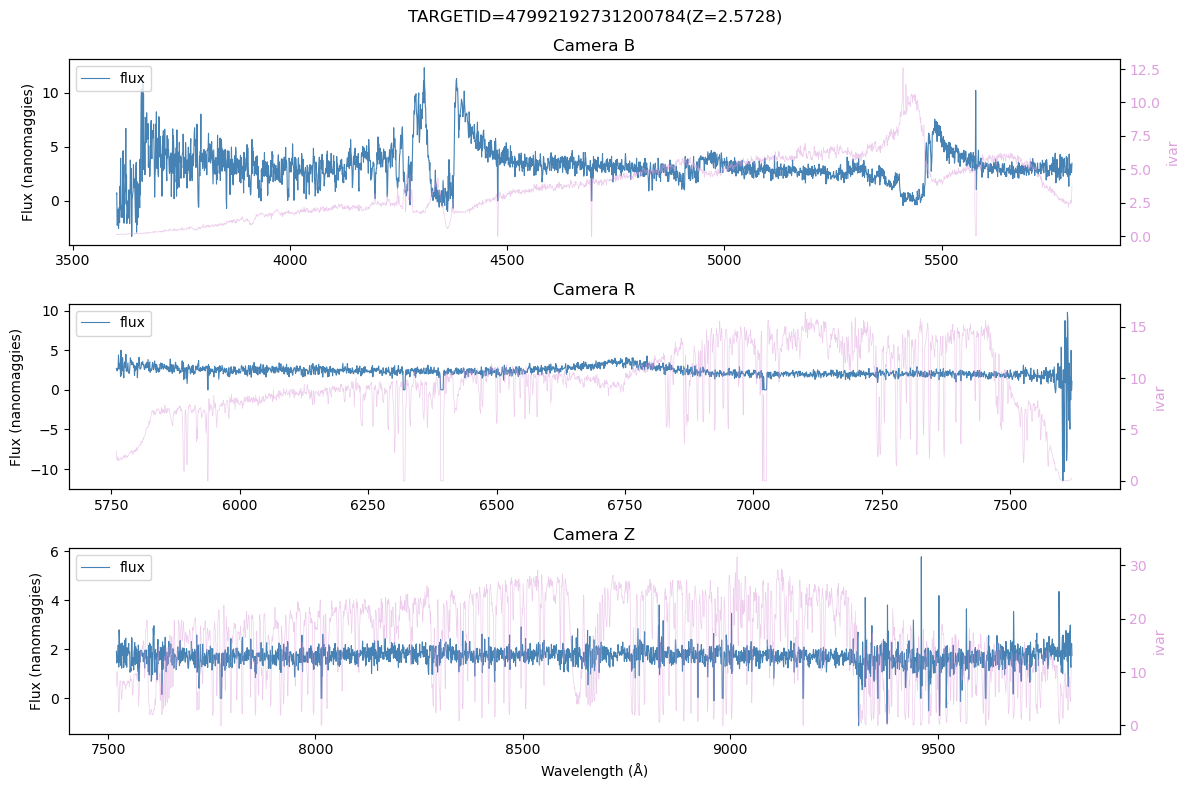

In [36]:
target_idx = 3

plot_spectra(df_object, target_idx)

In [37]:
# Print first 2 rows of dataframe - useful for copy/pasting into documentation

df_object.iloc[:2]

TARGETID  TARGET_RA  TARGET_DEC         Z  \
_healpix_29                                                             
47991521810220274  39628230637916670  23.190178   18.856721  1.489172   
47992039361544743  39628236367335481  23.165036   18.888546  0.880572   

                       ZERR  \
_healpix_29                   
47991521810220274  0.000865   
47992039361544743  0.000065   

                                                           spectra_b  \
_healpix_29                                                            
47991521810220274  [{wavelength: 3600.0, flux: 0.002376, ivar: 0....   
47992039361544743  [{wavelength: 3600.0, flux: 0.322199, ivar: 0....   

                                                           spectra_r  \
_healpix_29                                                            
47991521810220274  [{wavelength: 5760.0, flux: 0.180997, ivar: 2....   
47992039361544743  [{wavelength: 5760.0, flux: 7.639961, ivar: 0....   

                                                           spectra_z  \
_healpix_29                                                            
47991521810220274  [{wavelength: 7520.0, flux: 0.920303, ivar: 8....   
47992039361544743  [{wavelength: 7520.0, flux: -0.006492, ivar: 1...   

                             objectId   coord_ra  coord_dec  r_psfMag  \
_healpix_29                                                             
47991521810220274  805469645476725267  23.190189  18.856733      <NA>   
47992039361544743  805469645476725414  23.165003  18.888799      <NA>   

                   r_psfMagErr  _dist_arcsec  
_healpix_29                                   
47991521810220274         <NA>       0.05855  
47992039361544743         <NA>      0.919738

In [38]:
import hats

hats_cat = hats.read_hats("/sdf/data/rubin/user/olynn/desi_x_lsst_dp2_object")
hats_cat.aggregate_column_statistics()

,min_value,max_value,null_count,row_count
column_names,,,,
TARGETID,-1.193221e+08,6.160975e+17,0,1127685
TARGET_RA,6.814053e-05,3.600000e+02,0,1127685
TARGET_DEC,-1.481088e+01,2.071711e+01,0,1127685
Z,-4.305349e-03,6.942505e+00,0,1127685
ZERR,2.232146e-46,1.569150e-02,0,1127685
spectra_b.wavelength,3.600000e+03,5.800000e+03,0,3102261435
spectra_b.flux,-3.202671e+03,5.891808e+04,0,3102261435
spectra_b.ivar,-0.000000e+00,5.988957e+01,0,3102261435
spectra_b.mask,0.000000e+00,1.025000e+03,0,3102261435


## Performance analysis

In [39]:
# Generate markdown tables for the Dask dashboard reports

from dask_report_utils import client_table, metrics_table

print("Dia Objects:")
print(client_table("crossmatch_report_dia_obj.html", memory_limit_per_worker="14GB", threads_per_worker=2), "\n")
print(metrics_table("crossmatch_report_dia_obj.html"), "\n")

print("-----" * 8, "\n")

print("Objects:")
print(client_table("crossmatch_report_object.html", memory_limit_per_worker="14GB", threads_per_worker=2), "\n")
print(metrics_table("crossmatch_report_object.html"), "\n")

Dia Objects:
| Parameter | Value |
|---|---|
| Workers | 32 |
| Threads per worker | 2 |
| Total threads | 64 |
| Memory per worker | 14GB |
| Total memory | 417.23 GiB | 

| Metric | Value |
|---|---|
| Total tasks | 15750 |
| Wall time | 41m 49s |
| Compute time (all workers) | 2hr 39m |
| Transfer time | 36m 14s |
| Disk read time | 2.59 s |
| Disk write time | 2.06 s |
| Total bandwidth | N/A | 

---------------------------------------- 

Objects:
| Parameter | Value |
|---|---|
| Workers | 32 |
| Threads per worker | 2 |
| Total threads | 64 |
| Memory per worker | 14GB |
| Total memory | 417.23 GiB | 

| Metric | Value |
|---|---|
| Total tasks | 100000 |
| Wall time | 27m 57s |
| Compute time (all workers) | 5hr 14m |
| Transfer time | 4hr 20m |
| Disk read time | 2.06 s |
| Disk write time | 7.25 s |
| Total bandwidth | N/A | 



### 1. Setup
Both crossmatches were run on a USDF (S3DF) node using a local Dask distributed client. 

The full DESI DR1 Main Survey (Dark Program), accessed remotely over HTTPS from 
the NERSC portal (`https://portal.nersc.gov/project/cosmo/users/olynn/desi-dr1-main-dark/`), 
was crossmatched against the two catalogs:
- LSST DP2 dia_objects catalog (as of May 28, 2025), read locally from the USDF filesystem (`/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_6/dia_object_collection`)
- LSST DP2 objects catalog (as of June 1, 2025), read locally from the USDF filesystem (`/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_6/object_collection`)

The Dask client was configured as follows for both crossmatches:

| Parameter | Value |
|---|---|
| Workers | 32 |
| Threads per worker | 2 |
| Total threads | 64 |
| Memory per worker | 14 GB |
| Total memory | 417.23 GiB |

### 2. Wall Time

The full crossmatch--from the `desi.crossmatch(dp2).compute()` call to completion--took:
- **41m 49s** for `dia_objects`
- **27m 57s** for `objects`

Both crossmatches were run with the same Dask configuration, so the difference in wall time is driven by dataset size, task graph shape, and data transfer behavior rather than the cluster setup.

This reflects total wall time on a USDF (S3DF) node, including task graph
construction, data reads from the remote NERSC portal (DESI) and local filesystem (LSST DP2),
and the crossmatch computation itself. Sub-step timing was not recorded
separately; the Dask performance report in section 3 provides a finer-grained breakdown
of where time was spent.

### 3. Dask Performance Report
<div class="alert alert-warning">
<b>⚠︎ Large Task Graph</b>
During execution, Dask raised the following warning:
<pre><samp>
/sdf/group/rubin/sw/conda/envs/lsst-scipipe-13.0.0/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 38.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
</samp></pre>
</div>

This section reports Dask performance metrics for both crossmatches.

#### DESI × DP2 dia_objects

| Metric | Value |
|---|---|
| Total tasks | 15,750 |
| Wall time | 41m 49s |
| Compute time (all workers) | 2hr 39m |
| Transfer time | 36m 14s |
| Disk read time | 2.59s |
| Disk write time | 2.06s |
| Total bandwidth | N/A |

The Dask client ran with **2 threads per worker** (64 total threads across 32 workers). Aggregate compute time of **2hr 39m** across 32 workers gives roughly 5 minutes of compute per worker--broadly consistent with the 41m 49s wall time when accounting for scheduling overhead and imperfect parallelization across the task graph. Compute is the dominant cost; aggregate transfer time, while substantial, is secondary.

The **transfer time of 36m 14s** reflects data streaming from the NERSC portal. With 2 threads per worker, each worker had only 2 concurrent HTTP connections available to fetch DESI data, limiting per-worker transfer throughput.

Disk read of **2.59s** is small but non-zero, unlike the N/A reported in prior crossmatches. This likely reflects minor spilling to local disk during execution and is negligible relative to overall wall time. Disk write of **2.06s** is modest; as in prior runs, this figure may understate the true cost of `write_catalog()` if Dask does not register writes to a network-mounted USDF filesystem as local disk I/O. 

Total bandwidth was not reported by this version of the performance report.

#### DESI × DP2 objects

| Metric | Value |
|---|---|
| Total tasks | 100,000 |
| Wall time | 27m 57s |
| Compute time (all workers) | 5hr 14m |
| Transfer time | 4hr 20m |
| Disk read time | 2.06s |
| Disk write time | 7.25s |
| Total bandwidth | N/A |

This objects crossmatch processes a much larger catalog than the dia_objects run, but it still finished faster in wall-clock time because the workload was more effectively parallelized across workers.

Aggregate compute time of **5hr 14m** across 32 workers means roughly 9.8 minutes of compute per worker, which is consistent with the observed wall time once scheduling and parallel execution overlap are included. The larger task graph and higher task count also allow better worker utilization and load balancing, which can reduce idle time compared to the smaller dia_objects workload.

The **transfer time of 4hr 20m** is the largest non-compute component, showing that remote DESI data movement is a major contributor to overall runtime. Because transfer time is aggregated across workers, it can be much longer than the wall clock if many workers stream data concurrently.

Disk read and write times remain small in comparison, suggesting local I/O was not a primary bottleneck for this run.

Total bandwidth was not reported by this version of the performance report.